In [1]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.efficientnet import EfficientNetB0, preprocess_input
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping, ModelCheckpoint
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix

# reproducibility
tf.random.set_seed(42)
np.random.seed(42)


In [3]:
train_dir = '/content/drive/MyDrive/Colab Notebooks/plant Diseases Prediction/Train/Train'
val_dir   = '/content/drive/MyDrive/Colab Notebooks/plant Diseases Prediction/Validation/Validation'
test_dir  = '/content/drive/MyDrive/Colab Notebooks/plant Diseases Prediction/Test/Test'

IMG_SIZE = 224
BATCH_SIZE = 32


In [4]:
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=30,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    vertical_flip=True,
    fill_mode='nearest'
)

val_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)
test_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

train_gen = train_datagen.flow_from_directory(
    train_dir, target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE, class_mode='categorical',
    shuffle=True
)

val_gen = val_datagen.flow_from_directory(
    val_dir, target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE, class_mode='categorical',
    shuffle=False
)

test_gen = test_datagen.flow_from_directory(
    test_dir, target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE, class_mode='categorical',
    shuffle=False
)

labels = list(train_gen.class_indices.keys())
print("Classes:", labels)


Found 1322 images belonging to 3 classes.
Found 60 images belonging to 3 classes.
Found 150 images belonging to 3 classes.
Classes: ['Healthy', 'Powdery', 'Rust']


In [5]:
y = train_gen.classes
class_weights = compute_class_weight(class_weight='balanced', classes=np.unique(y), y=y)
class_weights = dict(enumerate(class_weights))
print("Class weights:", class_weights)


Class weights: {0: np.float64(0.9621542940320232), 1: np.float64(1.0248062015503876), 2: np.float64(1.0153609831029187)}


In [6]:
base_model = EfficientNetB0(weights='imagenet', include_top=False, input_shape=(IMG_SIZE, IMG_SIZE, 3))
base_model.trainable = False  # Freeze base

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.4)(x)
outputs = Dense(train_gen.num_classes, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=outputs)

model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()


16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 224, 224,  │          0 │ input_layer[0][0] │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization       │ (None, 224, 224,  │          7 │ rescaling[0][0]   │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_1         │ (None, 224, 224,  │          0 │ normalization[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 225, 225,  │          0 │ rescaling_1[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 112, 112,  │        864 │ stem_conv_pad[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 112, 112,  │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 112, 112,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 112, 112,  │        288 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 112, 112,  │        128 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 112, 112,  │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 32)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 32)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 8)   │        264 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 32)  │        288 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 112, 112,  │          0 │ block1a_activati… │
│ (Multiply)          │ 32)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 112, 112,  │        512 │ block1a_se_excit

 Total params: 4,053,414 (15.46 MB)

 Trainable params: 3,843 (15.01 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [7]:
checkpoint_path = '/content/drive/MyDrive/efficientnetb0_best.h5'
callbacks = [
    ModelCheckpoint(checkpoint_path, monitor='val_accuracy', save_best_only=True, mode='max', verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-7, verbose=1),
    EarlyStopping(monitor='val_loss', patience=6, restore_best_weights=True, verbose=1)
]


In [8]:
EPOCHS_HEAD = 15

history = model.fit(
    train_gen,
    epochs=EPOCHS_HEAD,
    validation_data=val_gen,
    callbacks=callbacks,
    class_weight=class_weights
)


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/15
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 10s/step - accuracy: 0.3630 - loss: 1.1450 
Epoch 1: val_accuracy improved from -inf to 0.48333, saving model to /content/drive/MyDrive/efficientnetb0_best.h5


42/42 ━━━━━━━━━━━━━━━━━━━━ 486s 11s/step - accuracy: 0.3638 - loss: 1.1442 - val_accuracy: 0.4833 - val_loss: 0.9932 - learning_rate: 1.0000e-04
Epoch 2/15
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.5033 - loss: 1.0043
Epoch 2: val_accuracy improved from 0.48333 to 0.63333, saving model to /content/drive/MyDrive/efficientnetb0_best.h5


42/42 ━━━━━━━━━━━━━━━━━━━━ 183s 4s/step - accuracy: 0.5042 - loss: 1.0033 - val_accuracy: 0.6333 - val_loss: 0.8510 - learning_rate: 1.0000e-04
Epoch 3/15
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.6263 - loss: 0.8650
Epoch 3: val_accuracy improved from 0.63333 to 0.80000, saving model to /content/drive/MyDrive/efficientnetb0_best.h5


42/42 ━━━━━━━━━━━━━━━━━━━━ 194s 4s/step - accuracy: 0.6266 - loss: 0.8646 - val_accuracy: 0.8000 - val_loss: 0.7394 - learning_rate: 1.0000e-04
Epoch 4/15
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.7387 - loss: 0.7387
Epoch 4: val_accuracy improved from 0.80000 to 0.86667, saving model to /content/drive/MyDrive/efficientnetb0_best.h5


42/42 ━━━━━━━━━━━━━━━━━━━━ 176s 4s/step - accuracy: 0.7386 - loss: 0.7387 - val_accuracy: 0.8667 - val_loss: 0.6487 - learning_rate: 1.0000e-04
Epoch 5/15
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.7680 - loss: 0.6994
Epoch 5: val_accuracy improved from 0.86667 to 0.91667, saving model to /content/drive/MyDrive/efficientnetb0_best.h5


42/42 ━━━━━━━━━━━━━━━━━━━━ 172s 4s/step - accuracy: 0.7683 - loss: 0.6989 - val_accuracy: 0.9167 - val_loss: 0.5764 - learning_rate: 1.0000e-04
Epoch 6/15
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.7854 - loss: 0.6435
Epoch 6: val_accuracy did not improve from 0.91667
42/42 ━━━━━━━━━━━━━━━━━━━━ 179s 4s/step - accuracy: 0.7862 - loss: 0.6429 - val_accuracy: 0.9167 - val_loss: 0.5177 - learning_rate: 1.0000e-04
Epoch 7/15
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.8370 - loss: 0.5860
Epoch 7: val_accuracy improved from 0.91667 to 0.93333, saving model to /content/drive/MyDrive/efficientnetb0_best.h5


42/42 ━━━━━━━━━━━━━━━━━━━━ 173s 4s/step - accuracy: 0.8369 - loss: 0.5857 - val_accuracy: 0.9333 - val_loss: 0.4688 - learning_rate: 1.0000e-04
Epoch 8/15
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.8483 - loss: 0.5385
Epoch 8: val_accuracy did not improve from 0.93333
42/42 ━━━━━━━━━━━━━━━━━━━━ 173s 4s/step - accuracy: 0.8486 - loss: 0.5382 - val_accuracy: 0.9333 - val_loss: 0.4317 - learning_rate: 1.0000e-04
Epoch 9/15
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.8678 - loss: 0.4919
Epoch 9: val_accuracy improved from 0.93333 to 0.95000, saving model to /content/drive/MyDrive/efficientnetb0_best.h5


42/42 ━━━━━━━━━━━━━━━━━━━━ 175s 4s/step - accuracy: 0.8679 - loss: 0.4919 - val_accuracy: 0.9500 - val_loss: 0.3983 - learning_rate: 1.0000e-04
Epoch 10/15
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.8894 - loss: 0.4548
Epoch 10: val_accuracy did not improve from 0.95000
42/42 ━━━━━━━━━━━━━━━━━━━━ 170s 4s/step - accuracy: 0.8892 - loss: 0.4548 - val_accuracy: 0.9500 - val_loss: 0.3695 - learning_rate: 1.0000e-04
Epoch 11/15
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.8843 - loss: 0.4516
Epoch 11: val_accuracy did not improve from 0.95000
42/42 ━━━━━━━━━━━━━━━━━━━━ 167s 4s/step - accuracy: 0.8845 - loss: 0.4513 - val_accuracy: 0.9500 - val_loss: 0.3478 - learning_rate: 1.0000e-04
Epoch 12/15
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.8948 - loss: 0.4199
Epoch 12: val_accuracy did not improve from 0.95000
42/42 ━━━━━━━━━━━━━━━━━━━━ 172s 4s/step - accuracy: 0.8951 - loss: 0.4197 - val_accuracy: 0.9500 - val_loss: 0.3275 - learning_rate: 1.0000e-04
Epoch 13/15
42/4

42/42 ━━━━━━━━━━━━━━━━━━━━ 190s 4s/step - accuracy: 0.9108 - loss: 0.3612 - val_accuracy: 0.9667 - val_loss: 0.2743 - learning_rate: 1.0000e-04
Restoring model weights from the end of the best epoch: 15.


In [9]:
base_model.trainable = True
N = 50  # Top 50 layers unfreeze
for layer in base_model.layers[:-N]:
    layer.trainable = False

model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

EPOCHS_FINE = 10
history_fine = model.fit(
    train_gen,
    epochs=EPOCHS_HEAD + EPOCHS_FINE,
    initial_epoch=history.epoch[-1] + 1 if len(history.epoch) else 0,
    validation_data=val_gen,
    callbacks=callbacks,
    class_weight=class_weights
)


Epoch 16/25
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.7440 - loss: 0.6509
Epoch 16: val_accuracy did not improve from 0.96667
42/42 ━━━━━━━━━━━━━━━━━━━━ 218s 5s/step - accuracy: 0.7439 - loss: 0.6509 - val_accuracy: 0.9500 - val_loss: 0.2564 - learning_rate: 1.0000e-05
Epoch 17/25
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.7913 - loss: 0.5431
Epoch 17: val_accuracy did not improve from 0.96667
42/42 ━━━━━━━━━━━━━━━━━━━━ 192s 5s/step - accuracy: 0.7917 - loss: 0.5426 - val_accuracy: 0.9500 - val_loss: 0.2587 - learning_rate: 1.0000e-05
Epoch 18/25
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.8254 - loss: 0.4920
Epoch 18: val_accuracy did not improve from 0.96667
42/42 ━━━━━━━━━━━━━━━━━━━━ 197s 5s/step - accuracy: 0.8262 - loss: 0.4908 - val_accuracy: 0.9500 - val_loss: 0.2447 - learning_rate: 1.0000e-05
Epoch 19/25
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.8908 - loss: 0.3992
Epoch 19: val_accuracy did not improve from 0.96667
42/42 ━━━━━━━━━━━━━━━━━━

42/42 ━━━━━━━━━━━━━━━━━━━━ 203s 5s/step - accuracy: 0.9099 - loss: 0.3420 - val_accuracy: 0.9833 - val_loss: 0.1989 - learning_rate: 1.0000e-05
Epoch 21/25
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.9526 - loss: 0.2750
Epoch 21: val_accuracy did not improve from 0.98333
42/42 ━━━━━━━━━━━━━━━━━━━━ 195s 5s/step - accuracy: 0.9522 - loss: 0.2753 - val_accuracy: 0.9833 - val_loss: 0.1762 - learning_rate: 1.0000e-05
Epoch 22/25
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.9682 - loss: 0.2415
Epoch 22: val_accuracy did not improve from 0.98333
42/42 ━━━━━━━━━━━━━━━━━━━━ 193s 5s/step - accuracy: 0.9679 - loss: 0.2418 - val_accuracy: 0.9833 - val_loss: 0.1541 - learning_rate: 1.0000e-05
Epoch 23/25
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.9423 - loss: 0.2494
Epoch 23: val_accuracy improved from 0.98333 to 1.00000, saving model to /content/drive/MyDrive/efficientnetb0_best.h5


42/42 ━━━━━━━━━━━━━━━━━━━━ 193s 5s/step - accuracy: 0.9426 - loss: 0.2488 - val_accuracy: 1.0000 - val_loss: 0.1351 - learning_rate: 1.0000e-05
Epoch 24/25
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.9632 - loss: 0.1943
Epoch 24: val_accuracy did not improve from 1.00000
42/42 ━━━━━━━━━━━━━━━━━━━━ 198s 5s/step - accuracy: 0.9632 - loss: 0.1943 - val_accuracy: 1.0000 - val_loss: 0.1199 - learning_rate: 1.0000e-05
Epoch 25/25
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.9654 - loss: 0.1961
Epoch 25: val_accuracy did not improve from 1.00000
42/42 ━━━━━━━━━━━━━━━━━━━━ 190s 4s/step - accuracy: 0.9655 - loss: 0.1958 - val_accuracy: 1.0000 - val_loss: 0.1044 - learning_rate: 1.0000e-05
Restoring model weights from the end of the best epoch: 25.


In [10]:
model.load_weights(checkpoint_path)

test_loss, test_acc = model.evaluate(test_gen)
print(f"Test loss: {test_loss:.4f}, Test accuracy: {test_acc:.4f}")


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


5/5 ━━━━━━━━━━━━━━━━━━━━ 47s 11s/step - accuracy: 0.8997 - loss: 0.2990
Test loss: 0.2016, Test accuracy: 0.9333


5/5 ━━━━━━━━━━━━━━━━━━━━ 21s 3s/step


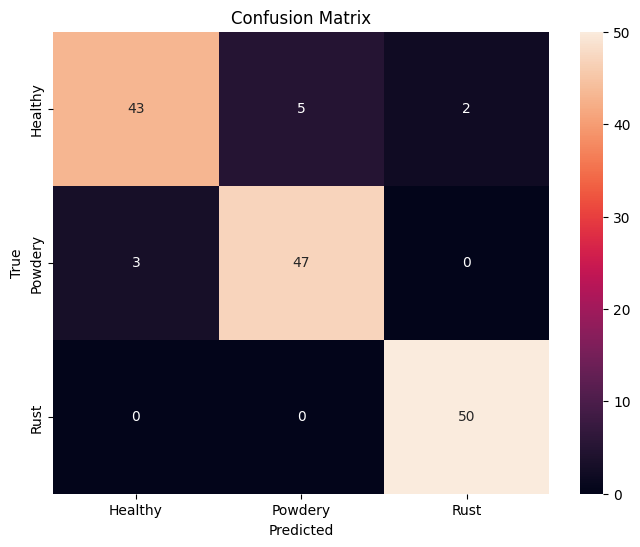

              precision    recall  f1-score   support

     Healthy       0.93      0.86      0.90        50
     Powdery       0.90      0.94      0.92        50
        Rust       0.96      1.00      0.98        50

    accuracy                           0.93       150
   macro avg       0.93      0.93      0.93       150
weighted avg       0.93      0.93      0.93       150



In [11]:
preds = model.predict(test_gen)
y_pred = np.argmax(preds, axis=1)
y_true = test_gen.classes

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=labels, yticklabels=labels)
plt.xlabel('Predicted'); plt.ylabel('True'); plt.title('Confusion Matrix')
plt.show()

print(classification_report(y_true, y_pred, target_names=labels))


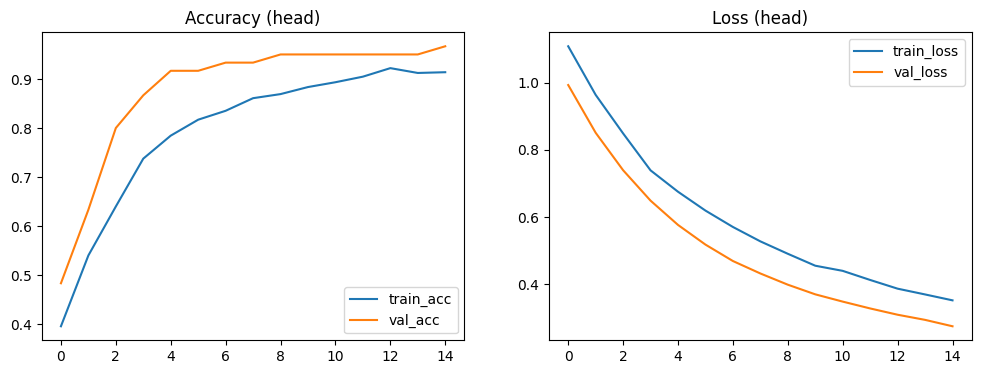

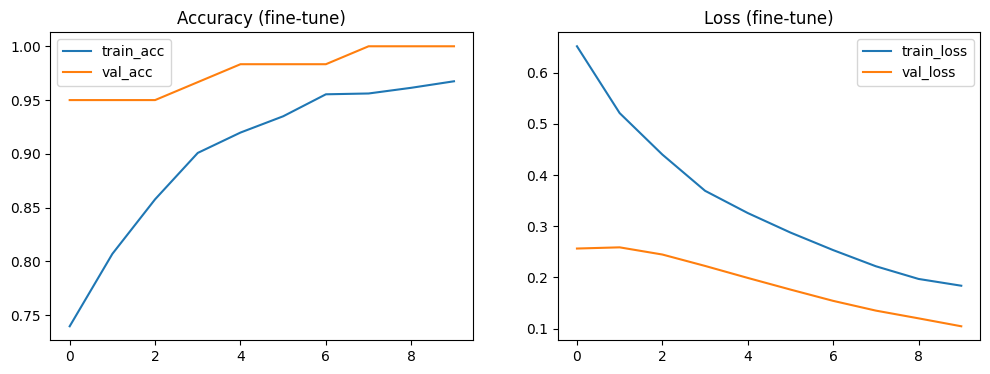

In [12]:
def plot_history(h, title_suffix=''):
    plt.figure(figsize=(12,4))
    plt.subplot(1,2,1)
    plt.plot(h.history['accuracy'], label='train_acc')
    plt.plot(h.history['val_accuracy'], label='val_acc')
    plt.title('Accuracy ' + title_suffix)
    plt.legend()
    plt.subplot(1,2,2)
    plt.plot(h.history['loss'], label='train_loss')
    plt.plot(h.history['val_loss'], label='val_loss')
    plt.title('Loss ' + title_suffix)
    plt.legend()
    plt.show()

plot_history(history, '(head)')
plot_history(history_fine, '(fine-tune)')


1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step


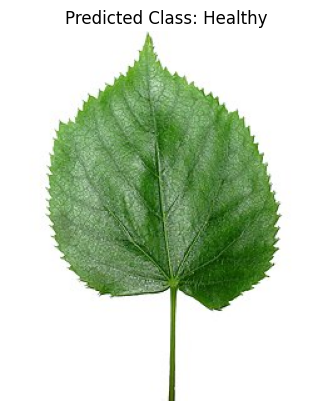

Prediction Probabilities:
Healthy: 0.5943
Powdery: 0.1612
Rust: 0.2444


In [13]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import os

# Assuming the model is trained and loaded into the 'model' variable
# and 'labels' are defined from the training data generator.

def process_image(image_path, img_size=224):
    """Loads and preprocesses an image for prediction."""
    img = Image.open(image_path).resize((img_size, img_size))
    img_array = tf.keras.utils.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)
    img_array = preprocess_input(img_array)  # Use the same preprocess_input as for training
    return img_array

# Define the path to the image
image_path = '/content/drive/MyDrive/l2.jpg'  # Change this path to your image file

# Check if the image file exists
if not os.path.exists(image_path):
    print(f"Error: Image not found at {image_path}. Please provide a valid path to your image file.")
else:
    # Load and preprocess the image
    processed_img_array = process_image(image_path, IMG_SIZE)

    # Load the original image for display
    original_img = Image.open(image_path)

    # Make a prediction using the trained model
    predictions = model.predict(processed_img_array)
    predicted_class_index = np.argmax(predictions, axis=1)[0]

    # Get the class name from the labels list
    predicted_class_name = labels[predicted_class_index]

    # Display the original image and the predicted class
    plt.imshow(original_img)
    plt.title(f'Predicted Class: {predicted_class_name}')
    plt.axis('off')
    plt.show()

    # Print the confidence scores for each class
    print("Prediction Probabilities:")
    for i, prob in enumerate(predictions[0]):
        print(f"{labels[i]}: {prob:.4f}")

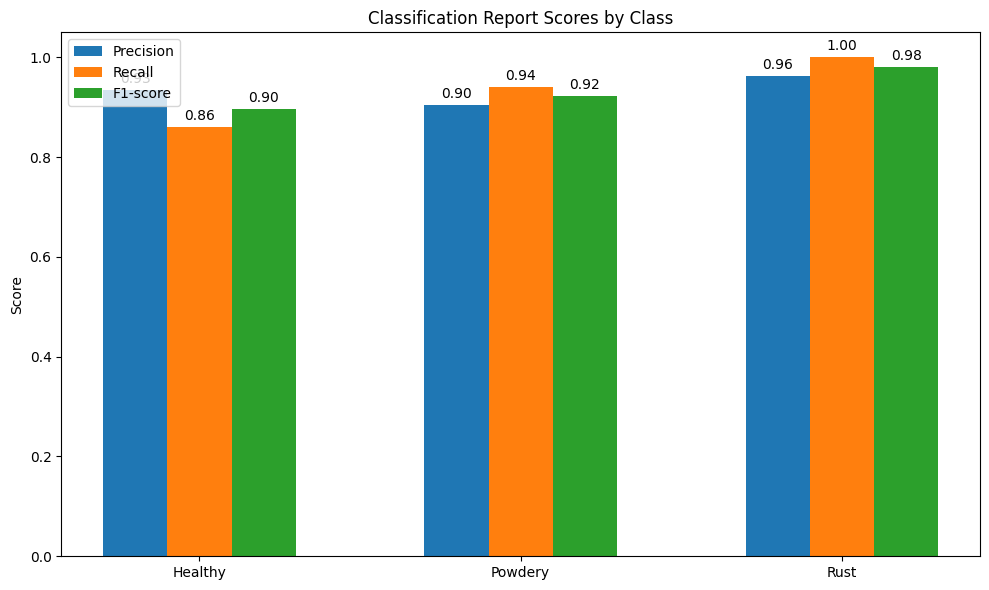

In [14]:
# Generate classification report
report = classification_report(y_true, y_pred, target_names=labels, output_dict=True)

# Extract precision, recall, and f1-score for each class
precision = [report[label]['precision'] for label in labels]
recall = [report[label]['recall'] for label in labels]
f1_score = [report[label]['f1-score'] for label in labels]

# Create the bar chart
x = np.arange(len(labels))
width = 0.2

fig, ax = plt.subplots(figsize=(10, 6))

rects1 = ax.bar(x - width, precision, width, label='Precision')
rects2 = ax.bar(x, recall, width, label='Recall')
rects3 = ax.bar(x + width, f1_score, width, label='F1-score')

# Add some text for labels, title and custom x-axis tick labels, etc.
ax.set_ylabel('Score')
ax.set_title('Classification Report Scores by Class')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend()

def autolabel(rects):
    """Attach a text label above each bar in *rects*, displaying its height."""
    for rect in rects:
        height = rect.get_height()
        ax.annotate('%.2f' % height,
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),  # 3 points vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom')

autolabel(rects1)
autolabel(rects2)
autolabel(rects3)

fig.tight_layout()
plt.show()